# Exercise 12

## Group ID: 22
*   Taha El Amine Kassabi
*   Mohamed Hazem Badawi
*   Carolin Goj

## Exercise day: Tuesday

### Description

## Exercise Overview

In this exercise, we will build a sentiment analysis classifier to identify hate speech and offensive language. We will achieve this by constructing a Transformer Encoder with a classification token. Your tasks in this assignment are as follows:

1. **Define Custom Multi-Head Attention Mechanism (2 points)**
   - Implement a custom multi-head attention mechanism without using the built-in `nn.MultiheadAttention`.

2. **Define Custom Transformer Encoder (2 points)**
   - Create a custom transformer encoder that utilizes the custom multi-head attention mechanism.

3. **Define Transformer Classifier (1 point)**
   - Develop a classifier that integrates the custom multi-head attention and transformer encoder. The classifier should use a classification token at the end.

Imports

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm, trange
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

Let's load the dataset we will be working with. The dataset contains three classes:

- **0**: Hate speech
- **1**: Offensive language
- **2**: Neither

In [2]:
data = pd.read_csv("labeled_data.csv")
data = data.loc[:, ["class", "tweet"]]

tweet_class_2 = data[data["class"] == 2].iloc[0]
tweet_class_1 = data[data["class"] == 1].iloc[0]
tweet_class_0 = data[data["class"] == 0].iloc[0]

train_data, test_data = train_test_split(data, test_size=0.2, random_state=1)

In [3]:
train_data.head(5)

,class,tweet
11746,1,Im prolly wit yo bitch big butt cant fit up in...
12823,1,Mei Haruka is tied up and takes three cocks in...
20436,0,RT @zachpiecowiak: @Eddie_Sativa87 you're a fu...
2182,2,.@CoryBooker is running around town delivering...
9288,1,Fuck these hoes im gone &#9996;&#65039;


In [4]:
test_data.head(5)

,class,tweet
13932,1,Pumpkin spice Marlboro's for da hoes
1636,1,&#8220;@_CiaraaaS: What things do you love? &#...
23100,2,Yankees should have NEVER gave away Melky. Guy...
3498,1,@Im_Thirst I love Louis CK! Quit bein a faggot...
12999,1,My boyfriend is such a smart ass bitch watch y...


Create a tokenizer and vocabulary. We will represent the strings as sequences of corresponding integer indices.

In [5]:
text = " ".join(data["tweet"])
chars = sorted(list(set(text)))
empty_char = '-'
chars.append(empty_char)
eol_char = '<'
chars.append(eol_char)

vocab_size = len(chars)

print(f'VOCAB: {"".join(chars)}')
print(f"\nVOCAB SIZE: {vocab_size}")

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

VOCAB: 
 !"#$%&'()*+,-./0123456789:;=?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[\]^_`abcdefghijklmnopqrstuvwxyz{|}~-<

VOCAB SIZE: 96


For simplicity let's create a DataLoaders

In [6]:
class TweetDataset(Dataset):
    def __init__(self, data, encode):
        self.data = data
        self.encode = encode

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        tweet = self.data.iloc[idx]["tweet"]
        label = self.data.iloc[idx]["class"]
        encoded_tweet = self.encode(tweet)
        return torch.tensor(encoded_tweet, dtype=torch.long), torch.tensor(label, dtype=torch.long)


train_dataset = TweetDataset(train_data, encode)
test_dataset = TweetDataset(test_data, encode)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                              collate_fn=lambda x: (torch.nn.utils.rnn.pad_sequence([i[0] for i in x], batch_first=True), torch.stack([i[1] for i in x])))
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                             collate_fn=lambda x: (torch.nn.utils.rnn.pad_sequence([i[0] for i in x], batch_first=True), torch.stack([i[1] for i in x])))

Define a `CustomMultiheadAttention`

In [7]:
class CustomMultiheadAttention(nn.Module):
    def __init__(self, embed_size, num_heads):
        assert embed_size % num_heads == 0, "embed_size must be divisible by num_heads"
        super(CustomMultiheadAttention, self).__init__()

        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads

        self.Q = nn.Linear(embed_size, embed_size)
        self.K = nn.Linear(embed_size, embed_size)
        self.V = nn.Linear(embed_size, embed_size)

        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        N, seq_length, embed_size = x.shape
        assert embed_size == self.num_heads * self.head_dim, "Embedding size mismatch"

        # transpose(1, 2) to go from dimensions (batch, sequence, head, embedding_values) to (batch, head, sequence, embedding_values)
        queries = self.Q(x).view(N, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.K(x).view(N, seq_length, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.V(x).view(N, seq_length, self.num_heads, self.head_dim).transpose(1, 2)

        energy = (queries @ keys.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attention = F.softmax(energy, dim=-1)

        out = (attention @ values).transpose(1, 2).contiguous().view(N, seq_length, embed_size)

        return self.fc_out(out)

Define a `CustomTransformerEncoderLayer` that utilizes `CustomMultiheadAttention` and a `CustomTransformerEncoder`.

In [8]:
class CustomTransformerEncoderLayer(nn.Module):
    def __init__(self, embed_size, num_heads, hidden_dim=2048):
        super(CustomTransformerEncoderLayer, self).__init__()
        self.self_attention = CustomMultiheadAttention(embed_size, num_heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_size)
        )

    def forward(self, x):
        attention = self.self_attention(x)
        x = self.norm1(x + attention)
        forward = self.feed_forward(x)
        return self.norm2(x + forward)


class CustomTransformerEncoder(nn.Module):
    def __init__(self, embed_size, num_heads, num_layers, hidden_dim=2048):
        super(CustomTransformerEncoder, self).__init__()
        self.layers = nn.ModuleList([
            CustomTransformerEncoderLayer(embed_size, num_heads, hidden_dim)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers: x = layer(x)
        return x

Define a `TransformerClassifier` that utilizes the `CustomTransformerEncoder`. The classifier is based on a classification token (`cls_token`). Below we describe overview of the initialization and forward pass should look like in `TransformerClassifier`

**Initialization**:

1. Embedding Layer: Converts input tokens to dense vectors.

2. Classification Token (`cls_token`): A learnable parameter added to the beginning of each input sequence.

3. Positional Embedding: Provides positional information to the model (excluding the classification token).

4. Custom Transformer Encoder: Processes the input sequence.

5. Fully Connected Layer: Maps the output to the desired number of classes.

**Forward Pass**:

Input shape is `(batch_size, seq_len)`.

1. Calculates Embedding: Converts input tokens to dense vectors of shape `(batch_size, seq_len, embed_size)`.

3. Concatenates cls_token to the beginning of the input sequence, resulting in `(batch_size, seq_len + 1, embed_size)`.

4. Add Positional Embedding: Adds positional embeddings to the input sequence (excluding the classification token), resulting in `(batch_size, seq_len + 1, embed_size)`.

5. Transformer Encoder: Processes the input sequence.

6. Classification: Extracts the output corresponding to the classification token and passes it through the fully connected layer to obtain class logits

In [9]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, num_heads, num_layers, num_classes, max_len):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_size))
        self.positional_embedding = nn.Parameter(torch.zeros(1, max_len + 1, embed_size))
        self.encoder = CustomTransformerEncoder(embed_size, num_heads, num_layers)
        self.fc = nn.Linear(embed_size, num_classes)

    def forward(self, x):
        N, seq_len = x.shape

        x = self.embedding(x)
        cls_tokens = self.cls_token.expand(N, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x += self.positional_embedding[:, :seq_len + 1, :]

        x = self.encoder(x)

        cls_output = x[:, 0, :]

        return self.fc(cls_output)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/620 [00:00<?, ?it/s]

Epoch 1/100, Loss: 0.6582348206831563


  0%|          | 0/620 [00:00<?, ?it/s]

Epoch 2/100, Loss: 0.6255193905964974


...

Epoch 98/100, Loss: 0.4647875744969614


  0%|          | 0/620 [00:00<?, ?it/s]

Epoch 99/100, Loss: 0.46270247971819295


  0%|          | 0/620 [00:00<?, ?it/s]

Epoch 100/100, Loss: 0.46241531384087375


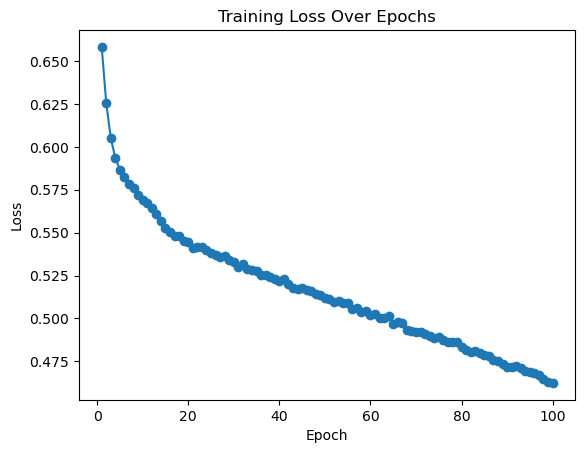

Training complete


In [10]:
# Play with those parameters to get better results
###################################
embed_size = 20
num_heads = 2
num_layers = 2
###################################

num_classes = 3
max_len = 1024

model = TransformerClassifier(vocab_size, embed_size, num_heads, num_layers, num_classes, max_len).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-5)

num_epochs = 100
loss_values = []

for epoch in trange(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_dataloader):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_dataloader)
    loss_values.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss}")

plt.plot(range(1, num_epochs + 1), loss_values, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

print("Training complete")

Evaluation (accuracy)

In [11]:
def calculate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    return accuracy


accuracy = calculate_accuracy(model, test_dataloader, device)
f"Test Accuracy: {accuracy * 100:.2f}%"

Evaluating:   0%|          | 0/155 [00:00<?, ?it/s]

'Test Accuracy: 79.58%'

Now we will display the most probable neutral tweet and the most hateful tweet from the test set.

In [12]:
def find_most_probable_tweets(model, dataloader, target_classes, decode_func, device):
    model.eval()
    best_tweets = {cls: {"prob": -1.0, "tweet": ""} for cls in target_classes}

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Processing Test Data"):
            inputs, labels = inputs.to(device), labels.to(device)
            probs = nn.functional.softmax(model(inputs), dim=1)

            for idx in range(inputs.size(0)):
                cls_label = labels[idx].item()
                if cls_label in target_classes:
                    prob_val = probs[idx][cls_label].item()
                    if prob_val > best_tweets[cls_label]["prob"]:
                        decoded = decode_func(inputs[idx].cpu().tolist()).strip()
                        decoded = re.sub(r'\s+', ' ', decoded)
                        best_tweets[cls_label].update({"prob": prob_val, "tweet": decoded})

    return best_tweets


target_classes = [0, 2]
most_probable_tweets = find_most_probable_tweets(model, test_dataloader, target_classes, decode, device)

for cls in target_classes:
    print(f"Most probable tweet for class {cls}:")
    print(f"Probability: {most_probable_tweets[cls]['prob'] * 100:.2f}%")
    print(f"Tweet: {most_probable_tweets[cls]['tweet']}")

Processing Test Data:   0%|          | 0/155 [00:00<?, ?it/s]

Most probable tweet for class 0:
Probability: 70.67%
Tweet: @godrocamora416 faggot
Most probable tweet for class 2:
Probability: 96.88%
Tweet: #HellYeah RT @BaconGawd #No RT @HuffingtonPost Happy Fall! Pumpkin Spice Oreos are here http://t.co/2prvsKantE http://t.co/hleYm0YC29
